## Stats Analysis

In [22]:
import pandas as pd

RUNS = list(range(1, 6))
BASE_PATH = "../statistics"

INVERSION_THRESHOLD = 0.25
WASSERSTEIN_THRESHOLD = 0.15
RECONSTRUCTION_THRESHOLD = 2
CCC_THRESHOLD = 0.8

METRICS = ["run", "var", "median_rmsd", "inversion_ratio", "wd_N-CA", "ccc"]

df_all = pd.read_csv(f"{BASE_PATH}/base/all_stats_rounded.csv")

df_test = df_all[df_all["key"] == "test_trans"].copy()
df_train = df_all[df_all["key"] == "train_both"].copy()
df_open = df_all[df_all["key"] == "train_closed"].copy()
df_closed = df_all[df_all["key"] == "train_closed"].copy()

df_pca = pd.read_csv(f"{BASE_PATH}/pca.csv")
df_umap = pd.read_csv(f"{BASE_PATH}/umap.csv")
df_mlp = pd.read_csv(f"{BASE_PATH}/mlp_hparam_tuned/33.csv")

### Model selection

In [ ]:
INVERSION_THRESHOLD = 0.15
WASSERSTEIN_THRESHOLD = 0.15
RECONSTRUCTION_THRESHOLD = 2
CCC_THRESHOLD = 0.85

var = 2
run = 1

df = df_train.copy()

# df_2 = df[
#     (df["var"] == var)
#     & (df["run"] == run)
#     & (df["inversion_ratio"] >= INVERSION_THRESHOLD)
#     & (df["wd_N-CA"] <= WASSERSTEIN_THRESHOLD)
#     & (df["ccc"] >= CCC_THRESHOLD)
# ]

# print(df_2[METRICS])


var = 14
run = 3

df_14 = df[
    (df["var"] == var)
    & (df["run"] == run)
    & (df["inversion_ratio"] >= INVERSION_THRESHOLD)
    & (df["wd_N-CA"] <= WASSERSTEIN_THRESHOLD)
    & (df["ccc"] >= CCC_THRESHOLD)
]

df_14[METRICS]

,run,var,median_rmsd,inversion_ratio,wd_N-CA,ccc
905,3.0,14.0,0.907,0.488,0.083,0.994


### Base models

In [ ]:
def style_table(df_split: pd.DataFrame, title: str):
    metric_cols = [
        "median_rmsd",
        "std_rmsd",
        "inversion_ratio",
        "wd_N-CA",
        "ccc",
    ]
    target = df_split.set_index("var")[metric_cols]

    def highlight(val, col):
        if col == "mean_rmsd" and val > RECONSTRUCTION_THRESHOLD:
            return "background-color: #f4cccc"
        if col == "inversion_ratio" and val < INVERSION_THRESHOLD:
            return "background-color: #f4cccc"
        if col == "wd_N-CA" and val > WASSERSTEIN_THRESHOLD:
            return "background-color: #f4cccc"
        if col == "ccc" and val < CCC_THRESHOLD:
            return "background-color: #f4cccc"
        return ""

    styled = target.style.apply(lambda s: [highlight(v, s.name) for v in s], axis=0)
    styled = styled.set_caption(title).format("{:.4f}")
    return styled


# New: Compute median and std across runs for each var
numeric_metric_cols = ["median_rmsd", "std_rmsd", "inversion_ratio", "wd_N-CA", "ccc"]

# Median table
median_metrics_both = (
    df_train.groupby("var")[numeric_metric_cols].median().reset_index()
)
median_metrics_test = df.groupby("var")[numeric_metric_cols].median().reset_index()

# Std table
std_metrics_both = df_train.groupby("var")[numeric_metric_cols].std().reset_index()
std_metrics_test = df.groupby("var")[numeric_metric_cols].std().reset_index()

# print("Median metrics (Train)")
# display(style_table(median_metrics_both, "Train Median"))
# print("Std metrics (Train)")
# display(style_table(std_metrics_both, "Train Std"))
# print("Median metrics (Test)")
# display(style_table(median_metrics_test, "Test Median"))
# print("Std metrics (Test)")
# display(style_table(std_metrics_test, "Test Std"))

In [ ]:
# Select models with median median RMSD for each latent dimension (var)
median_models = []
for v in sorted(df["var"].unique()):
    subset = df[df["var"] == v]
    sorted_subset = subset.sort_values("median_rmsd")
    n = len(sorted_subset)
    median_idx = n // 2
    median_row = sorted_subset.iloc[median_idx]
    median_models.append(median_row)

median_models_df = pd.DataFrame(median_models)

# Display as a styled table
metrics = ["var", "run", "median_rmsd", "std_rmsd", "inversion_ratio", "wd_N-CA", "ccc"]
display(style_table(median_models_df[metrics], "Median Model per Latent Dimension"))

### Fetching numbers

In [23]:
r_baseline = 1
v_baseline = 2

r_target = 3
v_target = 14

df_baseline_test = df_test[
    (df_test["run"] == r_baseline) & (df_test["var"] == v_baseline)
].copy()

print("=" * 60)
print("baseline")
print("=" * 60)
display(df_baseline_test[METRICS])

df_target_test = df_test[
    (df_test["run"] == r_target) & (df_test["var"] == v_target)
].copy()

print("=" * 60)
print("target")
print("=" * 60)
display(df_target_test[METRICS])


print("=" * 60)
print("PCA")
print("=" * 60)
df_pca_test = df_pca[df_pca["key"] == "test_trans"].copy()
display(df_pca_test[METRICS])


print("=" * 60)
print("UMAP")
print("=" * 60)
df_umap_test = df_umap[df_umap["key"] == "test_trans"].copy()
display(df_umap_test[METRICS])


print("=" * 60)
print("MLP")
print("=" * 60)
df_mlp_test = df_mlp[df_mlp["key"] == "test_trans"].copy()
display(df_mlp_test[METRICS])

baseline


,run,var,median_rmsd,inversion_ratio,wd_N-CA,ccc
60,1.0,2.0,2.132,0.392,0.119,0.873


target


,run,var,median_rmsd,inversion_ratio,wd_N-CA,ccc
246,3.0,14.0,1.633,0.223,0.1,0.972


PCA


,run,var,median_rmsd,inversion_ratio,wd_N-CA,ccc
0,3,14,2.043324,0.391875,0.079504,0.766777


UMAP


,run,var,median_rmsd,inversion_ratio,wd_N-CA,ccc
0,3,14,1.777744,0.26,0.098802,0.929074


MLP


,run,var,median_rmsd,inversion_ratio,wd_N-CA,ccc
0,3,14,2.015181,0.4925,0.089163,0.917954


### Line plots std

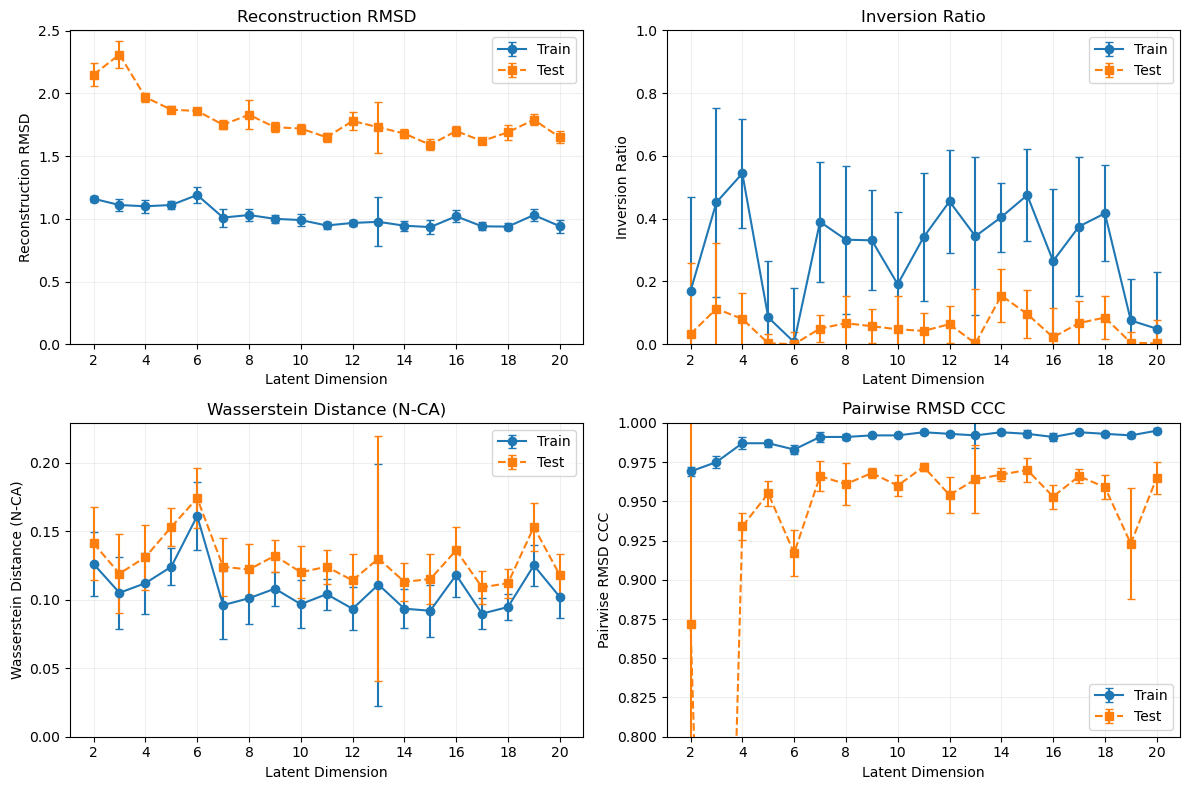

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def summarize_for_plot_std(df: "pd.DataFrame"):
    grouped = (
        df.groupby("var")
        .agg(
            median_rmsd=("median_rmsd", "median"),
            std_rmsd=("median_rmsd", "std"),
            inversion_ratio=("inversion_ratio", "median"),
            std_inversion=("inversion_ratio", "std"),
            wd_nca=("wd_N-CA", "median"),
            std_wd_nca=("wd_N-CA", "std"),
            ccc=("ccc", "median"),
            std_ccc=("ccc", "std"),
        )
        .reset_index()
        .sort_values("var")
    )
    grouped = grouped.fillna(0.0)
    return grouped


plot_train_std = summarize_for_plot_std(df_train)
plot_test_std = summarize_for_plot_std(df)

metrics_std = [
    ("median_rmsd", "std_rmsd", "Reconstruction RMSD"),
    ("inversion_ratio", "std_inversion", "Inversion Ratio"),
    ("wd_nca", "std_wd_nca", "Wasserstein Distance (N-CA)"),
    ("ccc", "std_ccc", "Pairwise RMSD CCC"),
]

x_min = int(min(plot_train_std["var"].min(), plot_test_std["var"].min()))
x_max = int(max(plot_train_std["var"].max(), plot_test_std["var"].max()))
xticks = list(range(x_min, x_max + 1, 2))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (value_col, std_col, title) in zip(axes.flat, metrics_std):
    ax.errorbar(
        plot_train_std["var"],
        plot_train_std[value_col],
        yerr=plot_train_std[std_col],
        fmt="o-",
        capsize=3,
        label="Train",
    )
    ax.errorbar(
        plot_test_std["var"],
        plot_test_std[value_col],
        yerr=plot_test_std[std_col],
        fmt="s--",
        capsize=3,
        label="Test",
    )

    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))
    if title in ("Inversion Ratio", "Pairwise RMSD CCC"):
        ax.set_ylim(0, 1)
    if title in ("Pairwise RMSD CCC"):
        ax.set_ylim(0.8, 1)
    elif title in ("Wasserstein Distance (N-CA)", "Reconstruction RMSD"):
        ax.set_ylim(bottom=0)
    ax.set_xlabel("Latent Dimension")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend()

fig.tight_layout()
plt.show()

### Line plots min / max

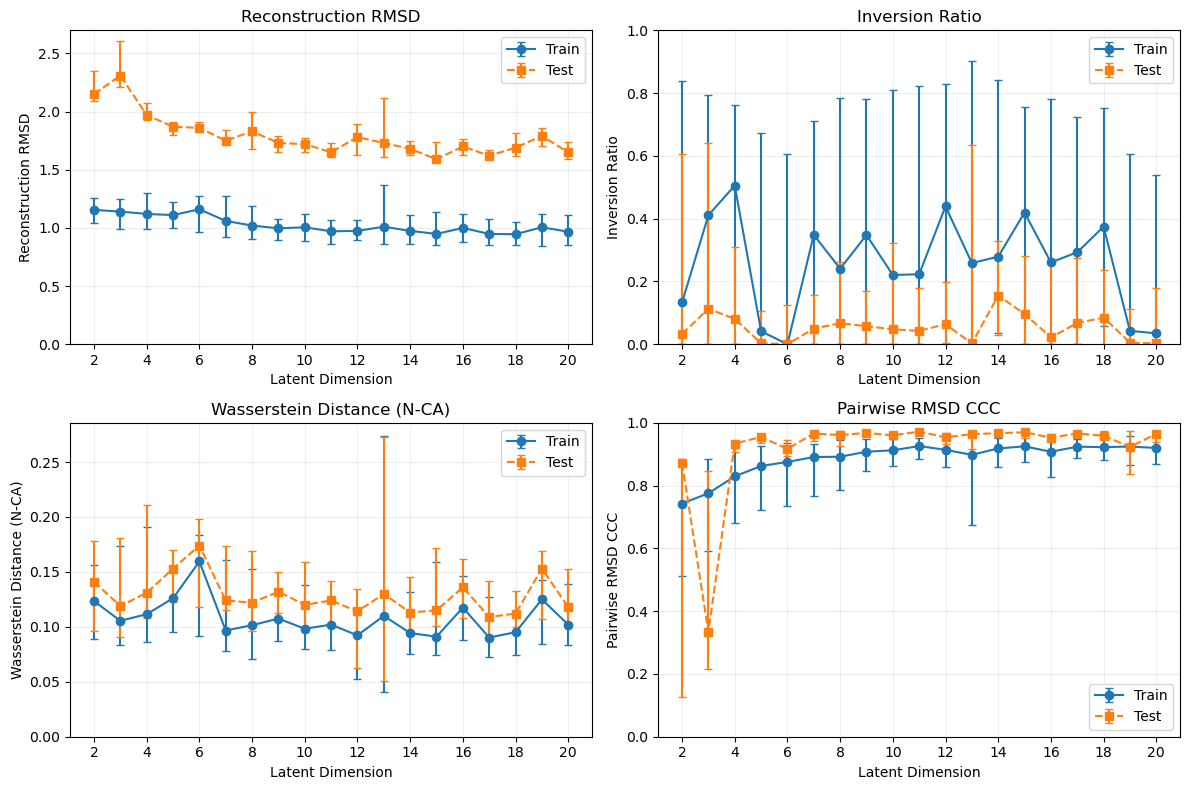

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def summarize_for_plot(df: "pd.DataFrame"):
    grouped = (
        df.groupby("var")
        .agg(
            median_rmsd=("median_rmsd", "median"),
            min_rmsd=("median_rmsd", "min"),
            max_rmsd=("median_rmsd", "max"),
            inversion_ratio=("inversion_ratio", "median"),
            inversion_min=("inversion_ratio", "min"),
            inversion_max=("inversion_ratio", "max"),
            wd_nca=("wd_N-CA", "median"),
            wd_nca_min=("wd_N-CA", "min"),
            wd_nca_max=("wd_N-CA", "max"),
            ccc=("ccc", "median"),
            ccc_min=("ccc", "min"),
            ccc_max=("ccc", "max"),
        )
        .reset_index()
        .sort_values("var")
    )

    grouped["rmsd_err_low"] = grouped["median_rmsd"] - grouped["min_rmsd"]
    grouped["rmsd_err_high"] = grouped["max_rmsd"] - grouped["median_rmsd"]
    grouped["inversion_err_low"] = grouped["inversion_ratio"] - grouped["inversion_min"]
    grouped["inversion_err_high"] = (
        grouped["inversion_max"] - grouped["inversion_ratio"]
    )
    grouped["wd_nca_err_low"] = grouped["wd_nca"] - grouped["wd_nca_min"]
    grouped["wd_nca_err_high"] = grouped["wd_nca_max"] - grouped["wd_nca"]
    grouped["ccc_err_low"] = grouped["ccc"] - grouped["ccc_min"]
    grouped["ccc_err_high"] = grouped["ccc_max"] - grouped["ccc"]

    err_cols = [
        "rmsd_err_low",
        "rmsd_err_high",
        "inversion_err_low",
        "inversion_err_high",
        "wd_nca_err_low",
        "wd_nca_err_high",
        "ccc_err_low",
        "ccc_err_high",
    ]
    grouped[err_cols] = grouped[err_cols].fillna(0.0)
    return grouped


plot_train = summarize_for_plot(df_train)
plot_test = summarize_for_plot(df)

metrics = [
    ("median_rmsd", "rmsd_err_low", "rmsd_err_high", "Reconstruction RMSD"),
    ("inversion_ratio", "inversion_err_low", "inversion_err_high", "Inversion Ratio"),
    ("wd_nca", "wd_nca_err_low", "wd_nca_err_high", "Wasserstein Distance (N-CA)"),
    ("ccc", "ccc_err_low", "ccc_err_high", "Pairwise RMSD CCC"),
]

x_min = int(min(plot_train["var"].min(), plot_test["var"].min()))
x_max = int(max(plot_train["var"].max(), plot_test["var"].max()))
xticks = list(range(x_min, x_max + 1, 2))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (value_col, err_low_col, err_high_col, title) in zip(axes.flat, metrics):
    train_yerr = [plot_train[err_low_col], plot_train[err_high_col]]
    test_yerr = [plot_test[err_low_col], plot_test[err_high_col]]

    ax.errorbar(
        plot_train["var"],
        plot_train[value_col],
        yerr=train_yerr,
        fmt="o-",
        capsize=3,
        label="Train",
    )
    ax.errorbar(
        plot_test["var"],
        plot_test[value_col],
        yerr=test_yerr,
        fmt="s--",
        capsize=3,
        label="Test",
    )

    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))
    if title in ("Inversion Ratio", "Pairwise RMSD CCC"):
        ax.set_ylim(0, 1)
    elif title in ("Wasserstein Distance (N-CA)", "Reconstruction RMSD"):
        ax.set_ylim(bottom=0)
    ax.set_xlabel("Latent Dimension")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend()

fig.tight_layout()
plt.show()

### Finding min and maxes for each stat

In [ ]:
from pprint import pprint

# Find the (var, run) with max and min for each statistic in df_all
stats = ["median_rmsd", "inversion_ratio", "wd_N-CA", "ccc"]
results = {}

for stat in stats:
    idx_max = df[stat].idxmax()
    idx_min = df[stat].idxmin()
    max_row = df.loc[idx_max, ["var", "run", stat]]
    min_row = df.loc[idx_min, ["var", "run", stat]]
    results[stat] = {
        "max": {"var": max_row["var"], "run": max_row["run"], "value": max_row[stat]},
        "min": {"var": min_row["var"], "run": min_row["run"], "value": min_row[stat]},
    }


pprint(results)

### MLP weight comparisons

In [35]:
import pandas as pd

paths = {
    0: "../statistics/mlp_stats_weight_0.csv",
    1: "../statistics/mlp_stats_weight_1.csv",
    2: "../statistics/mlp_stats_weight_2.csv",
    3: "../statistics/mlp_stats_weight_3.csv",
    4: "../statistics/mlp_stats_weight_4.csv",
    5: "../statistics/mlp_stats_weight_5.csv",
    6: "../statistics/mlp_stats_weight_6.csv",
    7: "../statistics/mlp_stats_weight_7.csv",
    8: "../statistics/mlp_stats_weight_8.csv",
    9: "../statistics/mlp_stats_weight_9.csv",
    10: "../statistics/mlp_stats_weight_10.csv",
    11: "../statistics/mlp_stats_weight_11.csv",
}

dfs = []
for weight, path in paths.items():
    df = pd.read_csv(path)
    df["weight"] = weight
    dfs.append(df)

df_weights = pd.concat(dfs, ignore_index=True)
df_weights_test = df_weights[df_weights["key"] == "test_trans"]

# df_weights_test

medians = [1, 4, 8, 9]
df_weights_test[df_weights_test["weight"].isin(medians)]

,var,run,key,median_rmsd,mean_rmsd,std_rmsd,ccc,inversion_ratio,wd_N-CA,wd_CA-C,wd_C-N,wd_CA-CB,weight
4,14,3,test_trans,2.266290,2.307358,0.532924,0.756476,0.414375,0.089552,0.104236,0.105421,0.088484,1
16,14,3,test_trans,23.676647,23.683233,1.144873,0.607822,0.000000,0.522217,0.614141,0.642954,0.483840,4
32,14,3,test_trans,2.105534,2.114005,0.492341,0.874870,0.560625,0.088494,0.100801,0.102814,0.086704,8
36,14,3,test_trans,24.503347,24.430185,0.773192,0.941640,0.000000,0.860579,1.129339,1.296796,0.796338,9
